# Compared with true referrence

内部 source 点数: 2248
边界点数: 300
patch 数: 49
evaluation 点数: 2248


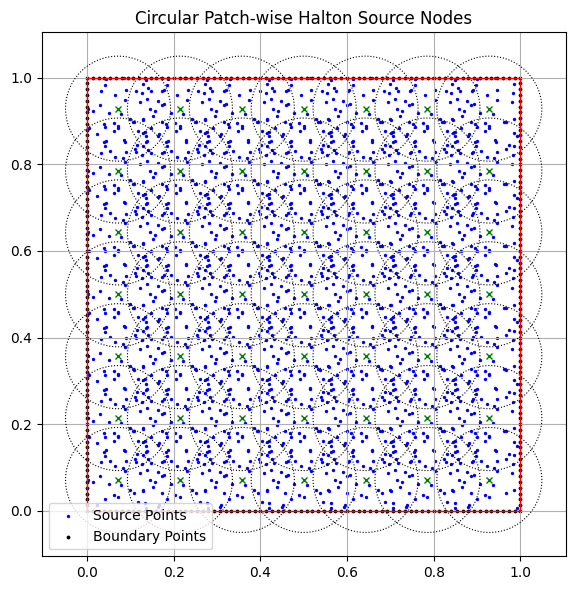

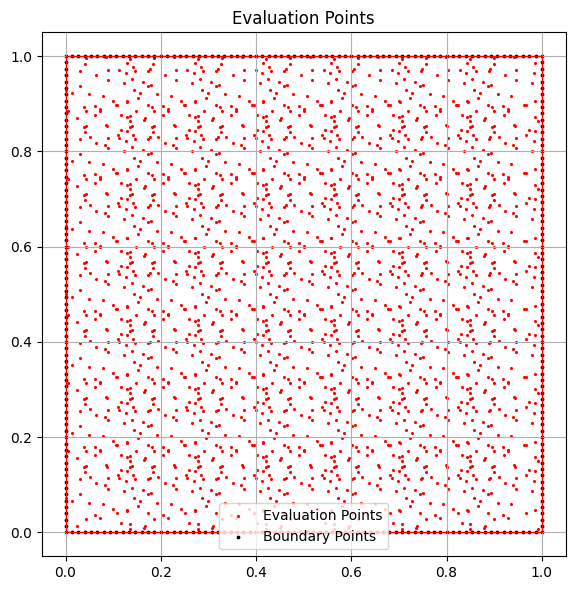

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =========================================================
# 1. van der Corput
# =========================================================
def vandercorput(n, base):
    n = np.asarray(n, dtype=np.int64)
    out = np.zeros_like(n, dtype=np.float64)

    denom = base
    current = n.copy()

    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current //= base
        denom *= base

    return out


# =========================================================
# 2. Halton sequence
# =========================================================
def halton_sequence(N, dim):
    primes = [2, 3, 5, 7, 11, 13]
    H = np.zeros((N, dim))
    idx = np.arange(1, N + 1)

    for j in range(dim):
        H[:, j] = vandercorput(idx, primes[j])

    return H


def generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
):
    """
    Square domain (0,1)^2
    Circular patches + patch-wise Halton nodes
    """

    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0

    # =====================================================
    # patch centers
    # =====================================================
    H = (x_max - x_min) / N_patch_grid

    x_centers = np.linspace(
        x_min + H / 2,
        x_max - H / 2,
        N_patch_grid
    )
    y_centers = np.linspace(
        y_min + H / 2,
        y_max - H / 2,
        N_patch_grid
    )

    Xc, Yc = np.meshgrid(x_centers, y_centers)
    centers = np.column_stack([Xc.ravel(), Yc.ravel()])

    R_patch = (1 + overlap) * np.sqrt(2) * H / 2
    R_all = R_patch * np.ones(centers.shape[0])

    ptch = {
        "C": centers,
        "R": R_all
    }

    # =====================================================
    # reference Halton disc
    # =====================================================
    Hq = halton_sequence(N_local_per_patch, 2)

    theta = 2 * np.pi * Hq[:, 0]
    r = np.sqrt(Hq[:, 1]) * R_patch

    X_ref = np.column_stack([
        r * np.cos(theta),
        r * np.sin(theta)
    ])

    # =====================================================
    # patch-wise source nodes
    # =====================================================
    X_inner_list = []

    for c in centers:
        X_local = X_ref + c

        mask = (
            (X_local[:, 0] >= x_min) &
            (X_local[:, 0] <= x_max) &
            (X_local[:, 1] >= y_min) &
            (X_local[:, 1] <= y_max)
        )

        X_inner_list.append(X_local[mask])

    X_inner = np.vstack(X_inner_list)

    # =====================================================
    # evaluation points
    # =====================================================
    if mode == "c-rbf-pum":
        grid_eval = X_inner.copy()

    elif mode == "ls-rbf-pum":
        n_eval = int(np.sqrt(X_inner.shape[0]) * 2)
        xe = np.linspace(x_min, x_max, n_eval)
        ye = np.linspace(y_min, y_max, n_eval)
        Xe, Ye = np.meshgrid(xe, ye)
        grid_eval = np.column_stack([Xe.ravel(), Ye.ravel()])

    else:
        raise ValueError("Unknown mode")

    # =====================================================
    # boundary points
    # =====================================================
    n_side = N_boundary // 4
    rem = N_boundary % 4
    counts = [n_side] * 4
    for i in range(rem):
        counts[i] += 1

    xb = np.linspace(x_min, x_max, counts[0], endpoint=False)
    bottom = np.column_stack([xb, y_min * np.ones_like(xb)])

    yr = np.linspace(y_min, y_max, counts[1], endpoint=False)
    right = np.column_stack([x_max * np.ones_like(yr), yr])

    xt = np.linspace(x_max, x_min, counts[2], endpoint=False)
    top = np.column_stack([xt, y_max * np.ones_like(xt)])

    yl = np.linspace(y_max, y_min, counts[3], endpoint=False)
    left = np.column_stack([x_min * np.ones_like(yl), yl])

    X_boundary = np.vstack([bottom, right, top, left])

    boundary_curve = np.array([
        [0, 0],
        [1, 0],
        [1, 1],
        [0, 1],
        [0, 0]
    ])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve


# =========================================================
# 4. Plot
# =========================================================
def plot_generator_points(
    X_inner,
    X_boundary,
    ptch,
    grid_eval,
    boundary_curve
):
    C = ptch["C"]
    R = ptch["R"]
    theta = np.linspace(0, 2 * np.pi, 200)

    # =========================
    # Figure 1
    # =========================
    plt.figure(figsize=(7, 6))
    ax = plt.gca()

    for i in range(C.shape[0]):
        x = C[i, 0] + R[i] * np.cos(theta)
        y = C[i, 1] + R[i] * np.sin(theta)

        ax.plot(x, y, 'k:', linewidth=0.8)
        ax.plot(C[i, 0], C[i, 1], 'gx', markersize=5)

    ax.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax.scatter(X_inner[:, 0], X_inner[:, 1],
               s=8, c='b', marker='.', label='Source Points')

    ax.scatter(X_boundary[:, 0], X_boundary[:, 1],
               s=12, c='k', marker='.', label='Boundary Points')

    ax.set_aspect('equal')
    ax.set_title('Circular Patch-wise Halton Source Nodes')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

    # =========================
    # Figure 2
    # =========================
    plt.figure(figsize=(7, 6))
    ax2 = plt.gca()

    ax2.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax2.scatter(grid_eval[:, 0], grid_eval[:, 1],
                s=6, c='r', marker='.', label='Evaluation Points')

    ax2.scatter(X_boundary[:, 0], X_boundary[:, 1],
                s=12, c='k', marker='.', label='Boundary Points')

    ax2.set_aspect('equal')
    ax2.set_title('Evaluation Points')
    ax2.grid(True)
    ax2.legend()
    plt.tight_layout()

    plt.show()


# =========================================================
# 5. Main
# =========================================================
if __name__ == "__main__":
    N_patch_grid = 7
    N_local_per_patch = 50
    N_boundary = 300
    overlap = 0.2
    mode = "c-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = \
        generator_points_square(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            mode
        )

    print("内部 source 点数:", X_inner.shape[0])
    print("边界点数:", X_boundary.shape[0])
    print("patch 数:", ptch["C"].shape[0])
    print("evaluation 点数:", grid_eval.shape[0])

    plot_generator_points(
        X_inner,
        X_boundary,
        ptch,
        grid_eval,
        boundary_curve
    )

In [13]:

import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import distance
from scipy.spatial.distance import cdist
from scipy.linalg import qr, solve_triangular
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = False)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = False)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False) 
        # self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        # self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        # self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()


def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
    """
    Parameters
    ----------
    y : array-like or tensor, shape (M, 2)
        Evaluation points.
    X : array-like or tensor, shape (K, 2)
        Source points.

    Returns
    -------
    phi_vals : ndarray, shape (M, K)
    lap_y    : ndarray, shape (M, K)
    grad_y   : ndarray, shape (M, K, 2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim() == 1:
        y = y.unsqueeze(0)      # (1, 2)
    M = y.shape[0]
    K = X.shape[0]
    n = y.shape[1]              # dimension (=2)
    # --------------------------------------------------
    # pairwise difference: (M, K, 2)
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]      # (M, K, 2)
    # radial distance: (M, K, 1)
    r = torch.norm(diff, dim=2, keepdim=True) # (M, K, 1)
    r = r.clamp(min=eps)
    r.requires_grad_(True)
    # --------------------------------------------------
    # radial basis evaluation
    # --------------------------------------------------
    phi_vals = phi_net(r)       # (M, K, 1)
    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # --------------------------------------------------
    # Laplacian wrt y
    # Δ_y φ = φ''(r) + (n-1)/r φ'(r)
    # --------------------------------------------------
    lap_y = d2phi_dr2 + (n - 1) / r * dphi_dr  # (M, K, 1)
    # --------------------------------------------------
    # Gradient wrt y
    # ∇_y φ = φ'(r) * (y - x) / r
    # --------------------------------------------------
    grad_y = dphi_dr * diff / r                # (M, K, 2)
    # --------------------------------------------------
    # reshape outputs
    # --------------------------------------------------
    phi_vals = phi_vals.squeeze(-1).detach().cpu().numpy()  # (M, K)
    lap_y    = lap_y.squeeze(-1).detach().cpu().numpy()     # (M, K)
    grad_y   = grad_y.detach().cpu().numpy()                # (M, K, 2)
    return phi_vals, lap_y, grad_y


def poly2D(Z, order):
    nj = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((nj, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def laplacian_poly2D(order, y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

# # ===========================================================
def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def shepard_weights(x, ptch_C, ptch_R):
    diff = x[:, None, :] - ptch_C[None, :, :]
    r_dist = np.linalg.norm(diff, axis=2)    # M × Nc
    r_scaled = r_dist / ptch_R[None, :]      # M × Nc
    Varphi_matrix = wendland_C2(r_scaled)    # M × Nc
    Sum_Varphi = np.sum(Varphi_matrix, axis=1, keepdims=True)  # M × 1
    Sum_Varphi = np.maximum(Sum_Varphi, 1e-12)
    W_matrix = Varphi_matrix / Sum_Varphi    # M × Nc
    return W_matrix

# # ===========================================================


def rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    order: polynomial order (1,2,3,...)
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    L = lil_matrix((M, N))
    LL = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
        # print("f:",f_func.shape,RHS[:M1,:].shape)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
        # print("g:",g_func.shape,RHS[-M2:,:].shape)
    else:
        raise ValueError("g_func must be callable or numpy array")

    dist_XC = cdist(X, patch_C)
    dist_Y1C = cdist(Yin, patch_C)
    dist_Y2C = cdist(Yb, patch_C)
    start_time = time.time()
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0]
        idx_Yin = np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0]
        idx_Yb = np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0]  # note: in gobal + M1
        idx_Y = np.concatenate([idx_Yin, M1 + idx_Yb], axis=0)
        
        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        # print(f"Patch {i+1}/{Nc}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")
        RHS_lap = np.zeros((nj+Norder,Mk_1))
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))
  
        Z = X[idx_X] #(nj,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-12) # (Mk,nj)
        ## --- AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        p_y = poly2D(Yk, order).T        # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]       # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj+Norder)
        w_ide = np.linalg.solve(AP,RHS_ide) # (nj + Norder, Mk)
        w_lap = np.linalg.solve(AP,RHS_lap) # (nj + Norder, Mk_1)
        # Shepard weight
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        # print(win.shape, w_lap.shape)
        Op_in =  win * w_lap[:nj,:];      # (nj, Mk_1)
        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Op_in.T
        # --- boundary condtion
        wbc = W_matrix[M1+idx_Yb,i][None, :]    # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]     # (nj, Mk_2)
        L[np.ix_(M1+idx_Yb, idx_X)] = L[np.ix_(M1+idx_Yb, idx_X)] + Op_bc.T
        # --- Evaluate Matrix for Y
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]         # (nj,Mk)
        LL[np.ix_(idx_Y,idx_X)] = LL[np.ix_(idx_Y,idx_X)] + IDE.T
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================\
    end_time = time.time()
    print("Compiling matrix cost ", end_time - start_time ,"seconds")
    L = L.tocsr()
    if M == N:
        UX = spsolve(L, RHS)
    else:
        print(f"when beginning to solve QR, L1.shape is {L.shape} and RHS.shape is {RHS.shape}")
        UX = qr_solve(L, RHS)
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = LL.tocsr()

    # cond_LI = np.linalg.cond(LL.todense())
    # print("cond(LI) =", cond_LI)

    UY = LL.dot(UX).reshape(-1,1) #LL is highly dependent on Y = [Yin;Yb]. 
    ## If wana to slove on X, need to recalculate LL(X);
    return UY,L,LL

def qr_solve(L, RHS):
    L_dense = L.toarray()
    max_val = 10.0 # 目标缩放量级
    M = L_dense.shape[0]
    row_max = np.abs(L_dense).max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    ratios = max_val / row_max
    L_dense *= ratios

    RHS *= ratios
    Q, R = np.linalg.qr(L_dense, mode='reduced')
    return np.linalg.solve(R, Q.T @ RHS)

Compiling matrix cost  2.457369327545166 seconds
L infity error in u: 5.312e-04
Relative L2 error in u: 5.100e-04


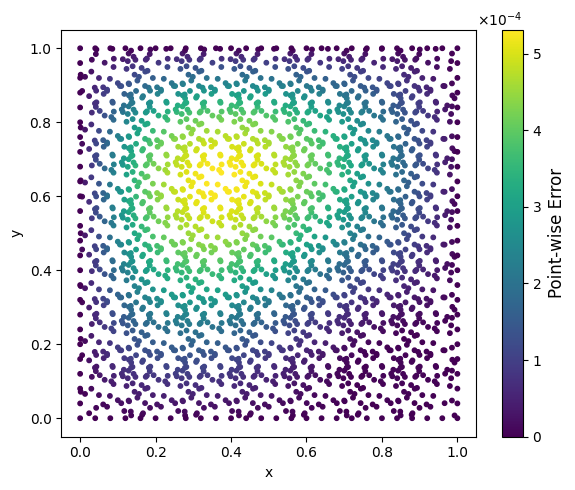

In [14]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 
# #===========================================================
# data = loadmat('./data_poisson/mydata_100_pdetool_4029_1.mat')
# p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
# index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# # print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
# X = p
# Y = X
# M = Y.shape[0]
# M2 = index_bc.shape[0]# 生成样本点已经给定
# M1 = M - M2
# # print(index_in.shape, index_bc.shape)
# K = 50
# testnum = 0
# Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
# f_func = f_new[index_in,testnum] 
# g_func = u_new[index_bc,testnum]
# order = 2
# reg = 1e-12
# u_true = u_new[:,testnum]
# u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)

# # ===========================================================
# u_func = lambda x, y: np.sin(x) * np.cos(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.cos(y)
# g_func = lambda x, y: np.sin(x) * np.cos(y)

u_func = lambda x, y: x * np.cos(y)
f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
g_func = lambda x, y: x * np.cos(y)
torchdtype = torch.float64

N_patch_grid = 7
N_local_per_patch = 50
N_boundary = 100
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
)

X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
reg = 1e-14
order = 3
u_true = u_func(Y[:,0:1], Y[:,1:2])
# # ===========================================================

UY,LL,L= rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
# print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'p={order}_error_200_rfm_fd_pu.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [15]:

import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import distance
from scipy.spatial.distance import cdist
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time

# from sksparse.spqr import spqr_factor

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(11.3880)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    nn.init.normal_(m.bias, mean=0.0, std=1)
                    # m.bias.data.zero_()

# # ===========================================================
# def wendland_C2(r):
#     return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4


# def rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
#     """
#     ptch: patch center and each radius
#     X:  (N,2)  RBF source points
#     Yin: (M1,2) interior points
#     Yb:  (M2,2) boundary points
#     f_func, g_func: Python callable returning torch tensor
#     K: number of neighbors
#     order: polynomial order (1,2,3,...)
#     """
#     patch_C = ptch['C']
#     patch_R = ptch['R']
#     Nc = patch_C.shape[0]
#     Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
#     # Combine evaluation points
#     Y = np.concatenate([Yin, Yb], axis=0)
#     # Compute distance to all source points
#     M = Y.shape[0]
#     N = X.shape[0]
#     M2 = Yb.shape[0] # number of boundary points
#     M1 = M - M2
#     W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
#     # Construct sparse L matrix
#     L = lil_matrix((M, N))
#     LL = lil_matrix((M, N))
#     # Construct RHS
#     RHS = np.zeros((M,1))
#     if callable(f_func):
#         RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
#     elif isinstance(f_func, np.ndarray):
#         RHS[:M1,:] = f_func[:,None] # (M1,1)
#         # print("f:",f_func.shape,RHS[:M1,:].shape)
#     else:
#         raise ValueError("f_func must be callable or numpy array")
#     if callable(g_func):
#         RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
#     elif isinstance(g_func, np.ndarray):
#         RHS[-M2:,:] = g_func[:,None] # (M2,1)
#         # print("g:",g_func.shape,RHS[-M2:,:].shape)
#     else:
#         raise ValueError("g_func must be callable or numpy array")

#     dist_XC = cdist(X, patch_C)
#     dist_Y1C = cdist(Yin, patch_C)
#     dist_Y2C = cdist(Yb, patch_C)

#     for i in range(Nc):
#         idx_X = np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0]
#         idx_Yin = np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0]
#         idx_Yb = np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0]  # note: in gobal + M1
#         idx_Y = np.concatenate([idx_Yin,M1 + idx_Yb])
    
#         Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
#         Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
#         Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
#         nj = idx_X.shape[0]
#         print(f"Patch {i+1}/{Nc}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")
#         RHS_lap = np.zeros((nj+Norder,Mk_1))
#         RHS_ide = np.ones((nj+Norder,Mk))
#         AP = np.zeros((nj+Norder,nj+Norder))
#         P = np.ones((nj,Norder))
  
#         Z = X[idx_X] #(nj,2)
#         dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
#         dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
#         Phi_jj = Phi(dist_ZZ) # (nj,nj)
#         Phi_jj = Phi_jj.detach().cpu().numpy()
#         phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)
#         ## --- AP
#         P = poly2D(Z, order)  # (nj,Norder)
#         AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
#         AP[nj:,:-Norder] = P.T # (Norder,nj)
#         ## --- RHS_lap(Yin), RHS_ide(Y)
#         lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
#         p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)
#         lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
#         RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
#         RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
#         RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
#         RHS_ide[nj:,:] = p_y            # (Norder, Mk)
#         # --- w_lap, w_ide
#         AP = AP + reg * np.eye(nj+Norder)
#         w_ide = np.linalg.solve(AP,RHS_ide) # (nj + Norder, Mk)
#         w_lap = np.linalg.solve(AP,RHS_lap) # (nj + Norder, Mk_1)
#         # Shepard weight
#         win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
#         # print(win.shape, w_lap.shape)
#         Op_in =  win * w_lap[:nj,:];      # (nj, Mk_1)
#         L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Op_in.T
#         # --- boundary condtion
#         wbc = W_matrix[M1+idx_Yb,i][None, :]    # (1, Mk_2)
#         Op_bc = wbc * w_ide[:nj,Mk_1:]     # (nj, Mk_2)
#         L[np.ix_(M1+idx_Yb, idx_X)] = L[np.ix_(M1+idx_Yb, idx_X)] + Op_bc.T
#         # --- Evaluate Matrix for Y
#         wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
#         IDE = wvec * w_ide[:nj,:]         # (nj,Mk)
#         LL[np.ix_(idx_Y,idx_X)] = LL[np.ix_(idx_Y,idx_X)] + IDE.T
#     # ===========================================================
#     # Solve linear system L U = RHS
#     # ===========================================================
#     L1 = L.tocsr()
#     if M == N:
#         UX = spsolve(L1, RHS)
#     else:
#         print(f"when beginning to solve QR, L1.shape is {L1.shape} and RHS.shape is {RHS.shape}")
#         # print(f"condition numbers is {np.linalg.cond(L1.toarray())}")
#         UX = qr_solve(L1.toarray(), RHS)

#     # ===========================================================
#     # Evaluate solution at Y
#     # ===========================================================
#     LL = LL.tocsr()
#     UY = LL.dot(UX).reshape(-1,1) #LL is highly dependent on Y = [Yin;Yb]. 
#     ## If wana to slove on X, need to recalculate LL(X);
#     return UY,L,LL

# def qr_solve(L, RHS):
#     Q, R = np.linalg.qr(L, mode='reduced')
#     return np.linalg.solve(R, Q.T @ RHS)


def test_solver(L, LL, RHS):
    """
    L  : (M,N) sparse operator matrix
    LL : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array
    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LL = LL.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]

    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS) # (N,Q)
    else:
        # least squares: solve column by column
        UX = qr_solve(L, RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LL @ UX                      # (M,Q)
    return UY


Number of patch centers:
 49
Compiling matrix cost  0.07297611236572266 seconds
(697, 1)
PoU L nnz = 34853
PoU LL nnz = 34853
boundary error: 1.998e-15
L infity error in u: 4.570e-02
Relative L2 error in u: 2.034e-02


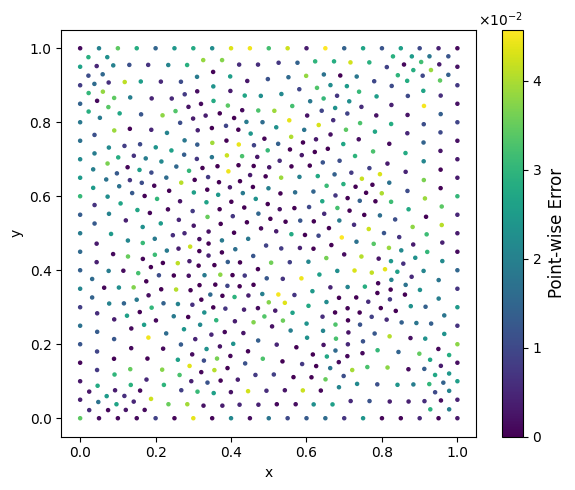

In [16]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

Phi = PhiNet(1, 50, 1).to(device) #
Phi.initi()
Phi = Phi.double() 

# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
data = loadmat('./data_poisson/mydata_100_pdetool_square_697.mat') # sigma = 1, l = 0.25
# data = loadmat('./data_poisson/mydata_100_pdetool_square_10201.mat') # sigma = 1, l = 0.25

p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (697, 1) (697, 1) (697, 2) (697, 100)
torchdtype = torch.float64

Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 1
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] # f_func only need interior points
g_func = u_new[index_bc,testnum]

order = 3
reg = 1e-14
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p

N_patch_grid = 7
N_local_per_patch = 10
N_boundary = 80
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
)
# X = np.vstack([X_inner, X_boundary])
# # ===========================================================

print("Number of patch centers:\n", ptch['C'].shape[0])

UY,L,LL = rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
print(u_true.shape)
print("PoU L nnz =", L.nnz)
print("PoU LL nnz =", LL.nnz)

error = np.abs(UY - u_true)
print(f'boundary error: {error[-M2:].max().item():.3e}') #,error[-M2:]
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/rfmfd_pu_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()


(697, 100) (617, 100) (80, 100)
p = 3, inference time: 0.0086 秒


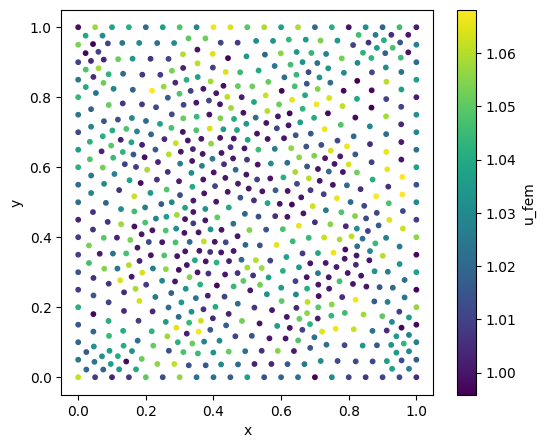

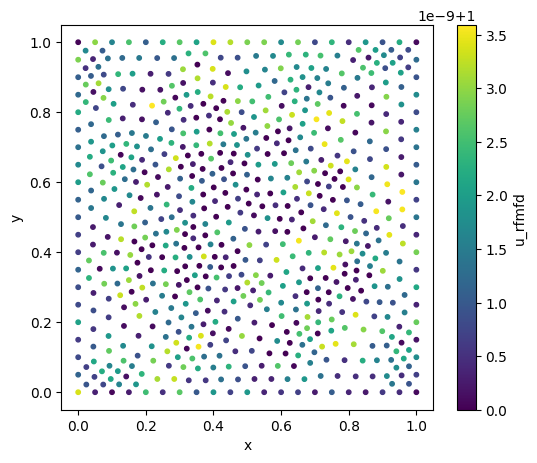

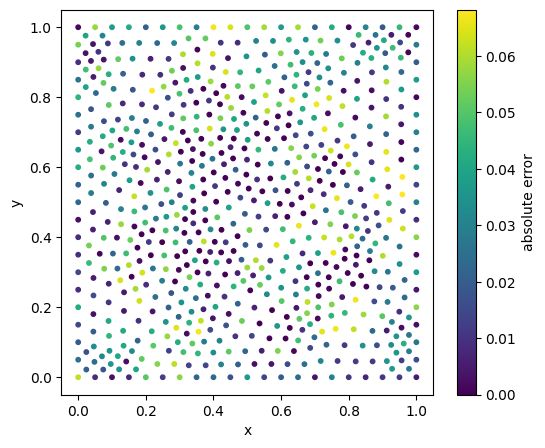

p = 3, test on 100 samples. The mean of max error: 5.327037e-02, and mean of relative L2 error: 2.407290e-02
p = 3, test on 100 samples. The variance of max error: 6.031704e-04, and variance of relative L2 error: 1.409047e-04


In [17]:
import time
torch.cuda.empty_cache()

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))

Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)

RHS = np.concatenate([f_vec,g_vec],axis = 0 )
start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(30)
q = np.random.randint(0, 5)

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_frmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=10)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

In [18]:

# import torch
# from scipy.io import loadmat
# import numpy as np
# import matplotlib.pyplot as plt
# import torch.nn as nn
# from scipy.spatial import distance
# from scipy.spatial.distance import cdist
# from scipy.linalg import qr, solve_triangular
# from scipy.sparse import lil_matrix
# from scipy.sparse.linalg import spsolve
# import matplotlib.pyplot as plt

# dtype = torch.float64
# device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# def relative_loss(predict, exact):
#     error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
#     return error

# def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
#     """
#     Parameters
#     ----------
#     y : array-like or tensor, shape (M, 2)
#         Evaluation points.
#     X : array-like or tensor, shape (K, 2)
#         Source points.

#     Returns
#     -------
#     phi_vals : ndarray, shape (M, K)
#     lap_y    : ndarray, shape (M, K)
#     grad_y   : ndarray, shape (M, K, 2)
#     """
#     y = torch.tensor(y, dtype=torch.float64, device=device)
#     X = torch.tensor(X, dtype=torch.float64, device=device)
#     if y.dim() == 1:
#         y = y.unsqueeze(0)      # (1, 2)
#     M = y.shape[0]
#     K = X.shape[0]
#     n = y.shape[1]              # dimension (=2)
#     # --------------------------------------------------
#     # pairwise difference: (M, K, 2)
#     # --------------------------------------------------
#     diff = y[:, None, :] - X[None, :, :]      # (M, K, 2)
#     # radial distance: (M, K, 1)
#     r = torch.norm(diff, dim=2, keepdim=True) # (M, K, 1)
#     r = r.clamp(min=eps)
#     r.requires_grad_(True)
#     # --------------------------------------------------
#     # radial basis evaluation
#     # --------------------------------------------------
#     phi_vals = phi_net(r)       # (M, K, 1)
#     # phi'(r)
#     dphi_dr = torch.autograd.grad(
#         outputs=phi_vals,
#         inputs=r,
#         grad_outputs=torch.ones_like(phi_vals),
#         create_graph=True,
#         retain_graph=True
#     )[0]                        # (M, K, 1)

#     # phi''(r)
#     d2phi_dr2 = torch.autograd.grad(
#         outputs=dphi_dr,
#         inputs=r,
#         grad_outputs=torch.ones_like(dphi_dr),
#         create_graph=False,
#         retain_graph=True
#     )[0]                        # (M, K, 1)
#     # --------------------------------------------------
#     # Laplacian wrt y
#     # Δ_y φ = φ''(r) + (n-1)/r φ'(r)
#     # --------------------------------------------------
#     lap_y = d2phi_dr2 + (n - 1) / r * dphi_dr  # (M, K, 1)
#     # --------------------------------------------------
#     # Gradient wrt y
#     # ∇_y φ = φ'(r) * (y - x) / r
#     # --------------------------------------------------
#     grad_y = dphi_dr * diff / r                # (M, K, 2)
#     # --------------------------------------------------
#     # reshape outputs
#     # --------------------------------------------------
#     phi_vals = phi_vals.squeeze(-1).detach().cpu().numpy()  # (M, K)
#     lap_y    = lap_y.squeeze(-1).detach().cpu().numpy()     # (M, K)
#     grad_y   = grad_y.detach().cpu().numpy()                # (M, K, 2)
#     return phi_vals, lap_y, grad_y

# # # ===========================================================
# def wendland_C2(r):
#     return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

# def shepard_weights(x, ptch_C, ptch_R):
#     diff = x[:, None, :] - ptch_C[None, :, :]
#     r_dist = np.linalg.norm(diff, axis=2)    # M × Nc
#     r_scaled = r_dist / ptch_R[None, :]      # M × Nc
#     Varphi_matrix = wendland_C2(r_scaled)    # M × Nc
#     Sum_Varphi = np.sum(Varphi_matrix, axis=1, keepdims=True)  # M × 1
#     Sum_Varphi = np.maximum(Sum_Varphi, 1e-12)
#     W_matrix = Varphi_matrix / Sum_Varphi    # M × Nc
#     return W_matrix

# def rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
#     """
#     ptch: patch center and each radius
#     X:  (N,2)  RBF source points
#     Yin: (M1,2) interior points
#     Yb:  (M2,2) boundary points
#     f_func, g_func: Python callable returning torch tensor
#     K: number of neighbors
#     order: polynomial order (1,2,3,...)
#     """
#     patch_C = ptch['C']
#     patch_R = ptch['R']
#     Nc = patch_C.shape[0]
#     Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
#     # Combine evaluation points
#     Y = np.concatenate([Yin, Yb], axis=0)
#     # Compute distance to all source points
#     M = Y.shape[0]
#     N = X.shape[0]
#     M2 = Yb.shape[0] # number of boundary points
#     M1 = M - M2
#     W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
#     # Construct sparse L matrix
#     L = lil_matrix((M, N))
#     LL = lil_matrix((M, N))
#     # Construct RHS
#     RHS = np.zeros((M,1))
#     if callable(f_func):
#         RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
#     elif isinstance(f_func, np.ndarray):
#         RHS[:M1,:] = f_func[:,None] # (M1,1)
#         # print("f:",f_func.shape,RHS[:M1,:].shape)
#     else:
#         raise ValueError("f_func must be callable or numpy array")
#     if callable(g_func):
#         RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
#     elif isinstance(g_func, np.ndarray):
#         RHS[-M2:,:] = g_func[:,None] # (M2,1)
#         # print("g:",g_func.shape,RHS[-M2:,:].shape)
#     else:
#         raise ValueError("g_func must be callable or numpy array")

#     def poly2D(Z, order):
#         nj = Z.shape[0]
#         Norder = (order+1)*(order+2)//2
#         P = np.zeros((nj, Norder))
#         idx = 0
#         for i in range(order+1):
#             for j in range(order+1-i):
#                 P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
#                 idx += 1
#         return P
#     def laplacian_poly2D(order, y):
#         y = np.asarray(y)
#         if y.ndim == 1:
#             y = y[None, :]     # (1, 2)
#         M = y.shape[0]
#         x = y[:, 0]           # (M,)
#         z = y[:, 1]           # (M,)
#         Norder = (order + 1) * (order + 2) // 2
#         lap = np.zeros((Norder, M))
#         idx = 0
#         for i in range(order + 1):
#             for j in range(order + 1 - i):
#                 val = np.zeros(M)
#                 if i >= 2:
#                     val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
#                 if j >= 2:
#                     val += j * (j - 1) * (x ** i) * (z ** (j - 2))
#                 lap[idx, :] = val
#                 idx += 1
#         return lap
#     dist_XC = cdist(X, patch_C)
#     dist_Y1C = cdist(Yin, patch_C)
#     dist_Y2C = cdist(Yb, patch_C)
#     dist_YC = cdist(Y, patch_C)
#     for i in range(Nc):
#         idx_X = np.where(dist_XC[:, i] <= patch_R[i] + 1e-12)[0]
#         idx_Yin = np.where(dist_Y1C[:, i] <= patch_R[i] + 1e-12)[0]
#         idx_Yb = np.where(dist_Y2C[:, i] <= patch_R[i] + 1e-12)[0]  # note: in gobal + M1
#         idx_Y  = np.where(dist_YC[:, i] <= patch_R[i] + 1e-12)[0]
#         Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
#         Yk_in,Yk_b = Yin[idx_Yin],Yb[idx_Yb]
#         Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
#         nj = idx_X.shape[0]
#         RHS_lap = np.zeros((nj+Norder,Mk_1))
#         RHS_ide = np.ones((nj+Norder,Mk))
#         AP = np.zeros((nj+Norder,nj+Norder))
#         P = np.ones((nj,Norder))
  
#         Z = X[idx_X] #(nj,2)
#         dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
#         dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
#         Phi_jj = Phi(dist_ZZ) # (nj,nj)
#         Phi_jj = Phi_jj.detach().cpu().numpy()
#         phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)
#         ## --- AP
#         P = poly2D(Z, order)  # (nj,Norder)
#         AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
#         AP[nj:,:-Norder] = P.T # (Norder,nj)
#         ## --- RHS_lap(Yin), RHS_ide(Y)
#         lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
#         p_y = poly2D(Yk, order).T        # (Mk,Norder).T = (Norder,Mk)
#         lap_phi = lap_phi[:Mk_1,:]        # (Mk,nj) --> (Mk_1,nj)
#         RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
#         RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
#         RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
#         RHS_ide[nj:,:] = p_y            # (Norder, Mk)
#         # --- w_lap, w_ide
#         AP = AP + reg * np.eye(nj+Norder)
#         w_ide = np.linalg.solve(AP,RHS_ide) # (nj + Norder, Mk)
#         w_lap = np.linalg.solve(AP,RHS_lap) # (nj + Norder, Mk_1)
#         # Shepard weight
#         win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
#         # print(win.shape, w_lap.shape)
#         Op_in =  win * w_lap[:nj,:];      # (nj, Mk_1)
#         L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Op_in.T
#         # --- boundary condtion
#         wbc = W_matrix[M1+idx_Yb,i][None, :]    # (1, Mk_2)
#         Op_bc = wbc * w_ide[:nj,Mk_1:]     # (nj, Mk_2)
#         L[np.ix_(M1+idx_Yb, idx_X)] = L[np.ix_(M1+idx_Yb, idx_X)] + Op_bc.T
#         # --- Evaluate Matrix for Y
#         wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
#         IDE = wvec * w_ide[:nj,:]         # (nj,Mk)
#         LL[np.ix_(idx_Y,idx_X)] = LL[np.ix_(idx_Y,idx_X)] + IDE.T
#     # ===========================================================
#     # Solve linear system L U = RHS
#     # ===========================================================
#     L1 = L.tocsr()
#     if M == N:
#         UX = spsolve(L1, RHS)
#     else:
#         print(f"when beginning to solve QR, L1.shape is {L1.shape} and RHS.shape is {RHS.shape}")
#         UX = qr_solve(L1.toarray(), RHS)
#     # ===========================================================
#     # Evaluate solution at Y
#     # ===========================================================
#     LL = LL.tocsr()
#     UY = LL.dot(UX).reshape(-1,1) #LL is highly dependent on Y = [Yin;Yb]. 
#     ## If wana to slove on X, need to recalculate LL(X);
#     return UY,L,LL

# def qr_solve(L, RHS):
#     Q, R = np.linalg.qr(L, mode='reduced')
#     return np.linalg.solve(R, Q.T @ RHS)

In [ ]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

Phi = PhiNet(1, 50, 1).to(device) #
Phi.initi()
Phi = Phi.double() 

# data = loadmat('./data_poisson/mydata_100_pdetool_square_697.mat') # sigma = 1, l = 0.25
data = loadmat('./data_poisson/mydata_100_pdetool_square_10201.mat') # sigma = 1, l = 0.25
p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64

Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 1
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]

order = 1
reg = 1e-14
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p

N_patch_grid = 20
N_local_per_patch = 10
N_boundary = 80
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
)
# X = np.vstack([X_inner, X_boundary]) donot need to generate new source points.
# # ===========================================================

UY,L,LL =  rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
# print(u_true.shape)
print("PoU L nnz =", L.nnz)
print("PoU LL nnz =", LL.nnz)

error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error[-M2:].max().item()) #,error[-M2:]
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/rfmfd_pu_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()


In [ ]:
import time
torch.cuda.empty_cache()

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))

Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)

RHS = np.concatenate([f_vec,g_vec],axis = 0 )
start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(30)
q = np.random.randint(0, 5)

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_frmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=10)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

Y.shape (10201, 2)
X.shape (10201, 2)
Compiling matrix cost  7.28378438949585 seconds
4.107825191113079e-15
L infity error in u: 2.949e-02
Relative L2 error in u: 1.310e-02


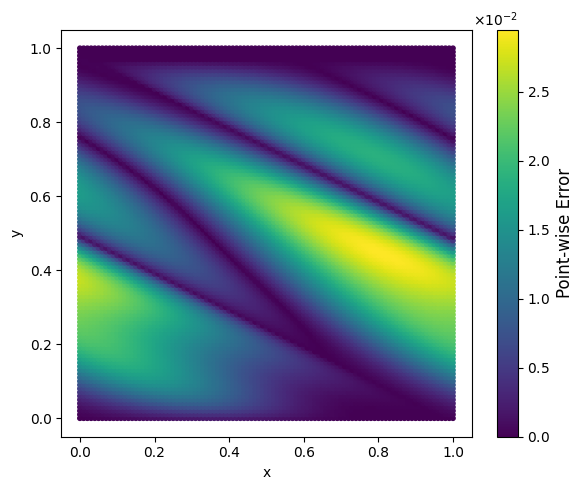

In [ ]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

Phi = PhiNet(1, 50, 1).to(device) #
Phi = Phi.double()

# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
# data = loadmat('./data_poisson/mydata_100_pdetool_square_697.mat') # sigma = 1, l = 0.25
data = loadmat('./data_poisson/mydata_100_pdetool_square_10201.mat') # sigma = 1, l = 0.25
p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64

Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 2
reg = 1e-12
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
print(f"Y.shape {Y.shape}")
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p
# N_patch_grid = 10
# N_local_per_patch = 50
# N_boundary = 400
# R_ptch = 0.8
# mode = "c-rbf-pum"
# # generate points
# X_inner, X_boundary, ptch, _ , _ = generator_points_square(
# N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
# X = np.vstack([X_inner, X_boundary])
print(f"X.shape {X.shape}")
# # ===========================================================

UY,L,LL =  rfm_fd_pu_poly_solve_poisson_nn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)

print(error[-M2:].max().item()) #,error[-M2:]

print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/rfmfd_pu_p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()


(10201, 100) (9801, 100) (400, 100)
p = 2, inference time: 5.1808 秒


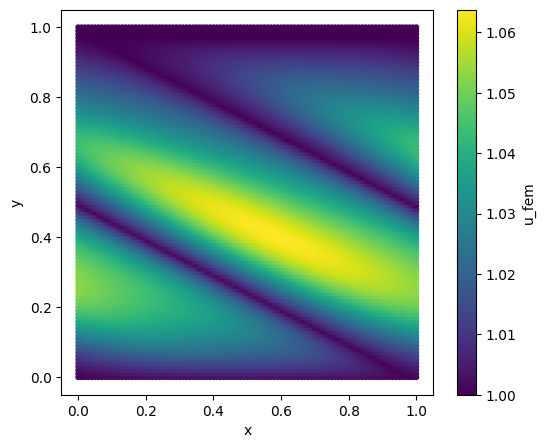

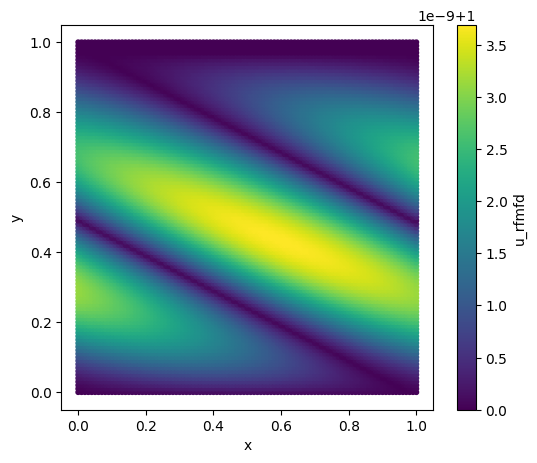

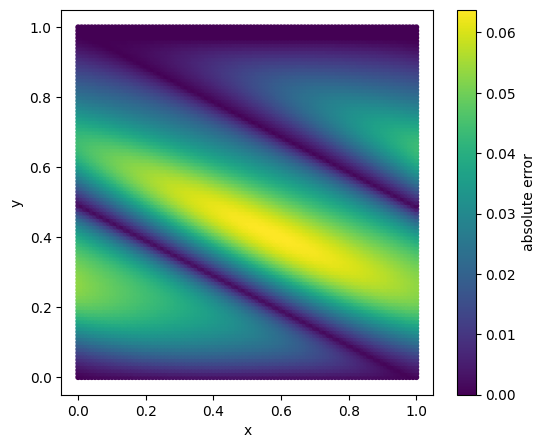

p = 2, test on 100 samples. The mean of max error: 5.357884e-02, and mean of relative L2 error: 2.405274e-02
p = 2, test on 100 samples. The variance of max error: 6.519225e-04, and variance of relative L2 error: 1.475849e-04


In [22]:

import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))

Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)

RHS = np.concatenate([f_vec,g_vec],axis = 0)

start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(30)
q = np.random.randint(0, 100)

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_u_frmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=10)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/rfmfd_pu_p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

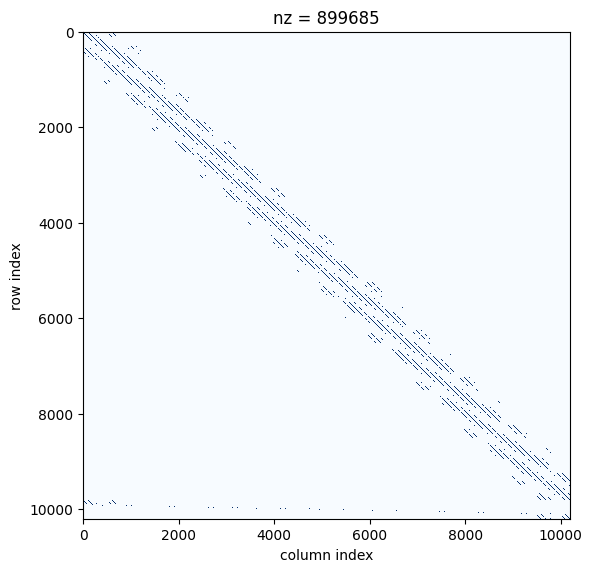

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(L)

In [ ]:
for name, param in Phi.named_parameters():
    print(name, param.data)

In [ ]:
import scipy.sparse as sp
def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(L)

In [ ]:
import numpy as np
error_cloinn = np.array([0.025198219266547753, 0.018980592235183953, 0.018172913500915797, 0.01406716711328216, 0.008694647330338041, 0.011190353264799887, 0.020788345360045875, 0.009379236385993542, 0.013207870645242413, 0.012025224176296681, 0.016698171878705665, 0.008716946431057082, 0.009546382899352111, 0.026774578128335884, 0.012266984183836385, 0.011183689200119844, 0.006452046096195871, 0.02208952592089042, 0.012990509411763959, 0.010784747383313684])
mean = np.mean(error_cloinn)
std = np.std(error_cloinn)
print(f"Mean: {mean:.3e}, Std: {std:.3e}")

error_fpi = np.array([1.900792979513977327e-02,
2.250779279203479061e-02,
1.495309159390947884e-02,
6.314227929855382310e-03,
5.138721258329863317e-03,
6.571636457491131407e-03,
1.835848506783485309e-02,
5.225773738536471091e-03,
8.283397244785535227e-03,
2.577026407690224605e-02,
1.169967630652640235e-02,
6.942655833243992734e-03,
4.303491098537805086e-03,
2.108715688236809105e-02,
1.070764681574885510e-02,
8.593906091089528396e-03])
mean_fpi = np.mean(error_fpi)
std_fpi = np.std(error_fpi)
print(f"Mean: {mean_fpi:.3e}, Std: {std_fpi:.3e}")